In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42

In [3]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[["v1", "v2"]]  # dropping the extra unnamed columns
df.columns = ["label", "message"]
print(df.shape)
df.head()

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(df["label"].value_counts())
spam_percent = (df["label"] == "spam").mean() * 100
print(f"spam makes up {spam_percent:.1f}% of the messages, kinda imbalanced but not as bad as the fraud dataset")

label
ham     4825
spam     747
Name: count, dtype: int64
spam makes up 13.4% of the messages, kinda imbalanced but not as bad as the fraud dataset


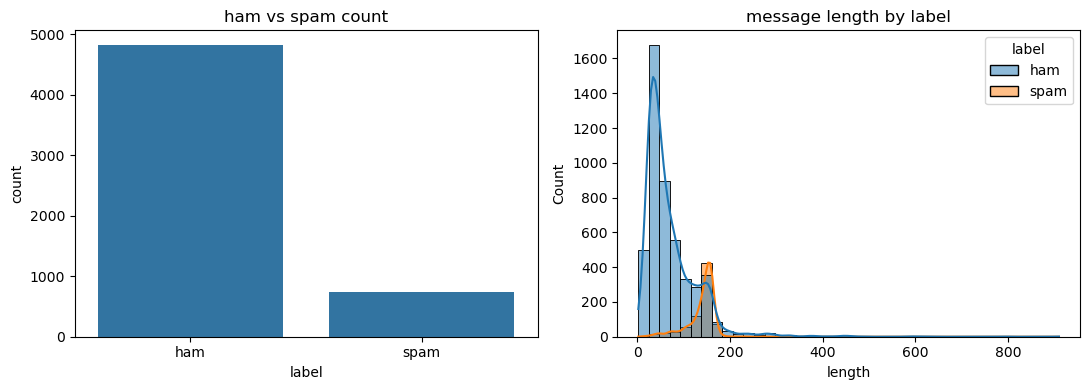

In [5]:
df["length"] = df["message"].apply(len)

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
sns.countplot(x="label", data=df)
plt.title("ham vs spam count")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x="length", hue="label", bins=40, kde=True)
plt.title("message length by label")
plt.tight_layout()
plt.savefig("eda_overview.png")
plt.show()

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove urls
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)  # remove numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)
df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [7]:
X = df["clean_message"]
y = df["label"].map({"ham": 0, "spam": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)


In [8]:
tfidf = TfidfVectorizer(max_features=3000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"train size: {X_train_tfidf.shape}, test size: {X_test_tfidf.shape}")


train size: (4457, 3000), test size: (1115, 3000)


In [9]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Linear SVM": LinearSVC(random_state=SEED),
}

for name, model in models.items():
    print(f"training {name}...")
    model.fit(X_train_tfidf, y_train)
print("done training")


training Naive Bayes...
training Logistic Regression...
training Linear SVM...
done training


In [10]:
for name, model in models.items():
    preds = model.predict(X_test_tfidf)

    print(name)
    print(f"accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, target_names=["ham", "spam"]))
    print("confusion matrix:")
    print(confusion_matrix(y_test, preds))
    print()


Naive Bayes
accuracy: 0.9704
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

confusion matrix:
[[965   1]
 [ 32 117]]

Logistic Regression
accuracy: 0.9650
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115

confusion matrix:
[[965   1]
 [ 38 111]]

Linear SVM
accuracy: 0.9865
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.91      0.95       149

    

In [11]:
sample_messages = [
    "Hey are we still meeting for lunch tomorrow?",
    "CONGRATULATIONS! You have WON a free iPhone, click here to claim now!!!",
    "Can you send me the notes from todays class",
    "URGENT: your account will be suspended, verify your details immediately",
]

best_model = models["Linear SVM"]  # went with this one, had the best f1 for spam in my testing

for msg in sample_messages:
    cleaned = clean_text(msg)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    label = "SPAM" if pred == 1 else "ham"
    print(f"[{label}] {msg}")


[ham] Hey are we still meeting for lunch tomorrow?
[SPAM] CONGRATULATIONS! You have WON a free iPhone, click here to claim now!!!
[ham] Can you send me the notes from todays class
[SPAM] URGENT: your account will be suspended, verify your details immediately
